# ABM Construction Safety — Exploration Notebook

**Based on:** Zhang et al. (2025, ASCE JCEM)  
**Author:** Daniil Marchici  
**Date:** September 2026

This notebook walks through the mathematical foundation of the model,
the CPT formulas, and the simulation results.

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt

from src.cpt import (
    value_function, weight_gain, weight_loss,
    compute_cpt_safe, compute_cpt_unsafe,
)
from src.model import SafetyModel

%matplotlib inline

c:\Users\Роман\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Value Function (Eq. 10)

The CPT value function:
$$v(x) = \begin{cases} (x-A)^\alpha & \text{if } x > A \\ -\lambda(A-x)^\beta & \text{if } x \le A \end{cases}$$

where $A$ is the reference point, $\alpha, \beta$ are sensitivity parameters,
and $\lambda$ is the loss aversion coefficient.

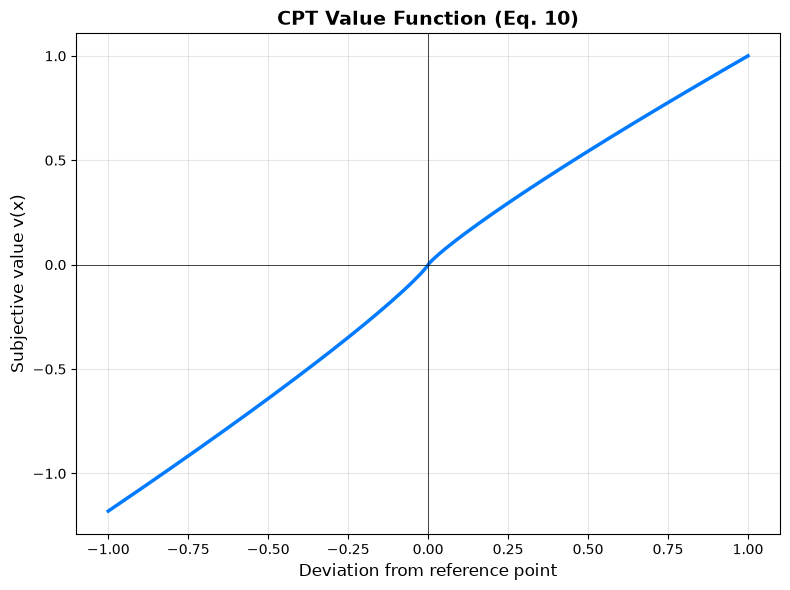

In [2]:
x = np.linspace(-1, 1, 200)
A = 0.0  # reference point at zero

v = value_function(x, A)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(x, v, color='#007bff', linewidth=2.5)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_xlabel('Deviation from reference point', fontsize=12)
ax.set_ylabel('Subjective value v(x)', fontsize=12)
ax.set_title('CPT Value Function (Eq. 10)', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Probability Weight Functions (Eq. 12–13)

$$w^+(P) = \frac{P^\gamma}{(P^\gamma + (1-P)^\gamma)^{1/\gamma}}$$

$$w^-(P) = \frac{P^\delta}{(P^\delta + (1-P)^\delta)^{1/\delta}}$$

Note how small probabilities get overweighted.

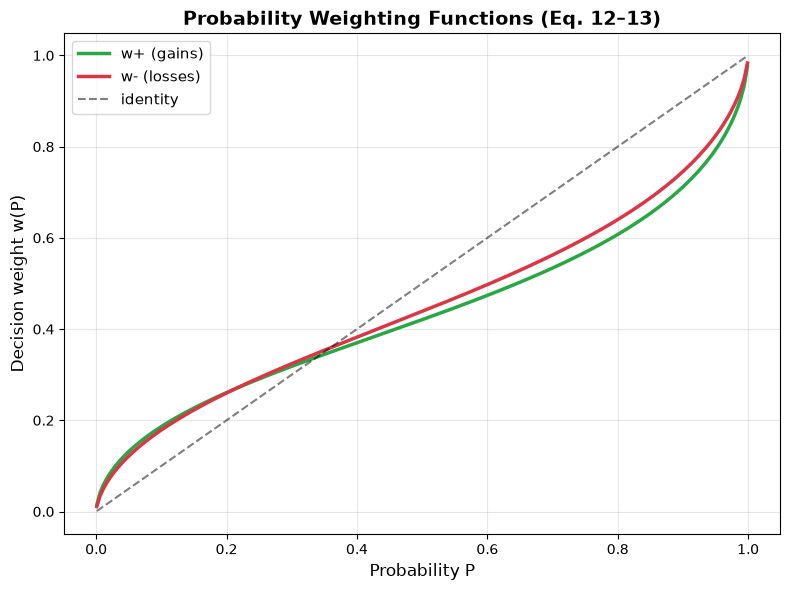

In [3]:
p = np.linspace(0.001, 0.999, 200)

wg = weight_gain(p)
wl = weight_loss(p)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(p, wg, label='w+ (gains)', color='#28a745', linewidth=2.5)
ax.plot(p, wl, label='w- (losses)', color='#dc3545', linewidth=2.5)
ax.plot(p, p, 'k--', alpha=0.5, label='identity')
ax.set_xlabel('Probability P', fontsize=12)
ax.set_ylabel('Decision weight w(P)', fontsize=12)
ax.set_title('Probability Weighting Functions (Eq. 12–13)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. CPT for Safe vs Unsafe Behavior (Eq. 14–15)

At reference point $A = 0.6$, unsafe behavior has strongly negative
CPT (accident weight), while safe behavior has milder negative CPT.

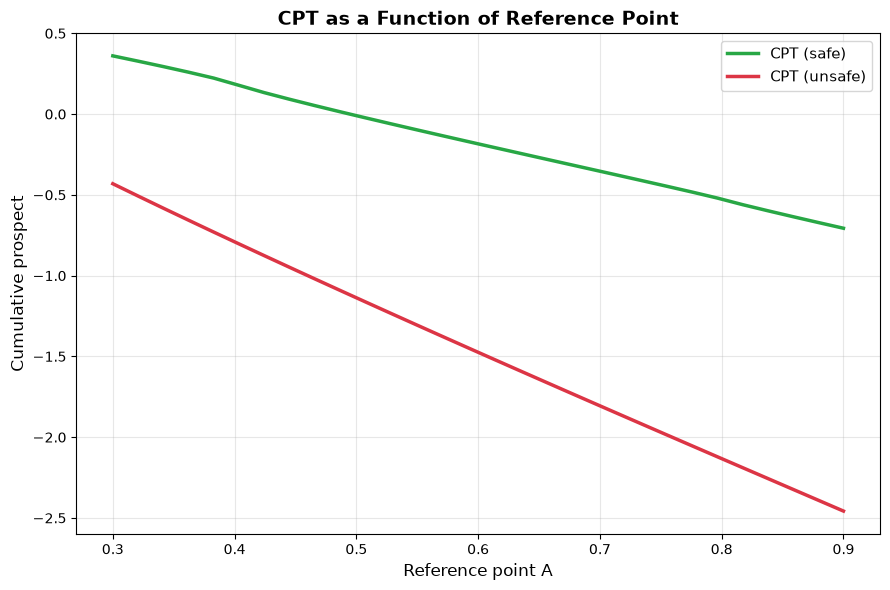

In [4]:
refs = np.linspace(0.3, 0.9, 30)
cpt_s = [compute_cpt_safe(reference_point=r) for r in refs]
cpt_u = [compute_cpt_unsafe(reference_point=r) for r in refs]

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(refs, cpt_s, label='CPT (safe)', color='#28a745', linewidth=2.5)
ax.plot(refs, cpt_u, label='CPT (unsafe)', color='#dc3545', linewidth=2.5)
ax.set_xlabel('Reference point A', fontsize=12)
ax.set_ylabel('Cumulative prospect', fontsize=12)
ax.set_title('CPT as a Function of Reference Point', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Full Simulation (100 workers × 100 days, seed=42)

In [5]:
model = SafetyModel(num_workers=100, num_managers=3, seed=42)
model.run(steps=100)

print(f"Initial safe rate: {model.safety_rate_history[0]:.2%}")
print(f"Final safe rate:   {model.safety_rate_history[-1]:.2%}")
print(f"Paper reference:   90.4%")

c:\Users\Роман\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\mesa\mesa_logging.py:112: FutureWarning: The use of the `seed` keyword argument is deprecated, use `rng` instead. No functional changes.
  res = func(*args, **kwargs)


Initial safe rate: 25.00%
Final safe rate:   91.00%
Paper reference:   90.4%


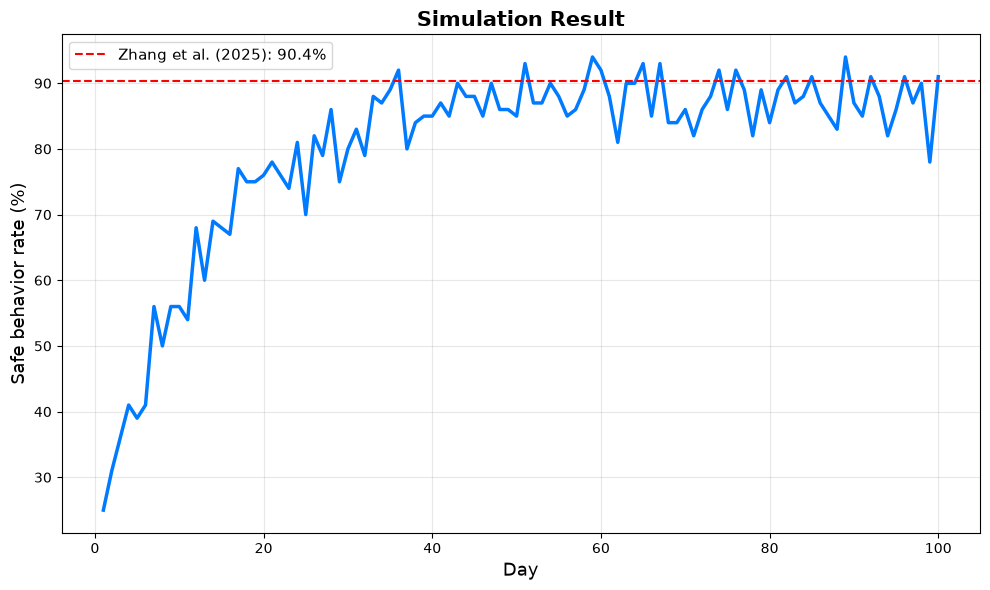

In [6]:
days = np.arange(1, 101)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(days, [r * 100 for r in model.safety_rate_history],
        color='#007bff', linewidth=2.5)
ax.axhline(y=90.4, color='red', linestyle='--',
           label='Zhang et al. (2025): 90.4%')
ax.set_xlabel('Day', fontsize=13)
ax.set_ylabel('Safe behavior rate (%)', fontsize=13)
ax.set_title('Simulation Result', fontsize=15, fontweight='bold')
ax.grid(alpha=0.3)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()